In [14]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn          
import torch.nn.init as init    
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Configuramos el estilo de las gráficas para que se vean más profesionales
sns.set_theme(style="whitegrid")

# Fijamos una semilla para que el azar sea siempre el mismo 
torch.manual_seed(42)
np.random.seed(42)



In [ ]:

df = pd.read_csv('insurance.csv')


# Exploratory Data Analysis (EDA):

In [3]:
print("--- PRIMERAS FILAS DEL DATASET ---")
display(df.head())

print("\n--- INFORMACIÓN GENERAL Y VALORES NULOS ---")
display(df.info())
print("Valores nulos por columna:\n", df.isnull().sum())

print("\n--- ESTADÍSTICAS DESCRIPTIVAS ---")
display(df.describe())

--- PRIMERAS FILAS DEL DATASET ---


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520



--- INFORMACIÓN GENERAL Y VALORES NULOS ---
<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 73.3 KB


None

Valores nulos por columna:
 age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

--- ESTADÍSTICAS DESCRIPTIVAS ---


,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


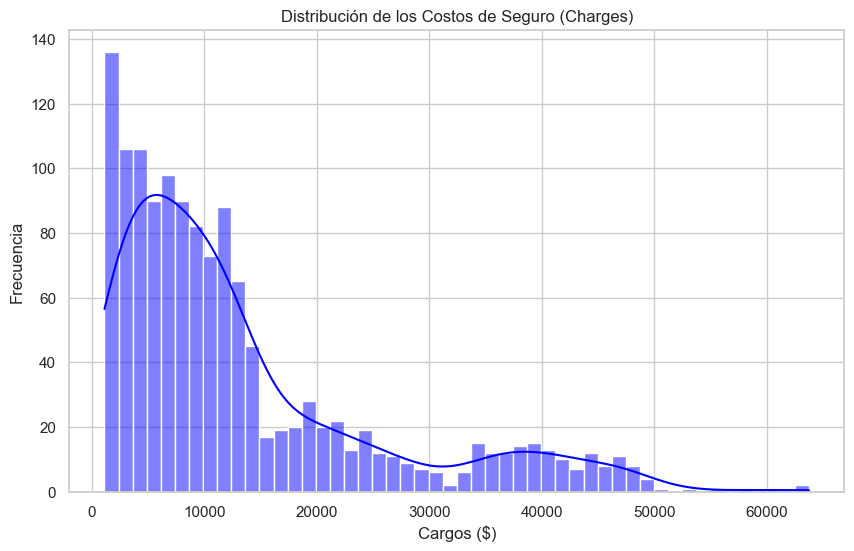

In [4]:
plt.figure(figsize=(10, 6))
sns.histplot(df['charges'], kde=True, color='blue', bins=50)
plt.title('Distribución de los Costos de Seguro (Charges)')
plt.xlabel('Cargos ($)')
plt.ylabel('Frecuencia')
plt.show()

In [5]:

# Transformamos categorías en columnas de 0 y 1 ya que nuestro modelo no puede trabajar con texto porque las redes neuronales trabajan con números, no con texto.
df = pd.get_dummies(df, columns=['sex', 'smoker', 'region'], drop_first=True)   #el drop_first=True es para evitar redundacia, es decir que si no es hombre, entonces es mujer, si no es fumador, entonces es no fumador, etc.

# Separamos las características (X) de la variable objetivo (y) que es 'charges'. 
X = df.drop('charges', axis=1).values
y = df['charges'].values.reshape(-1, 1)



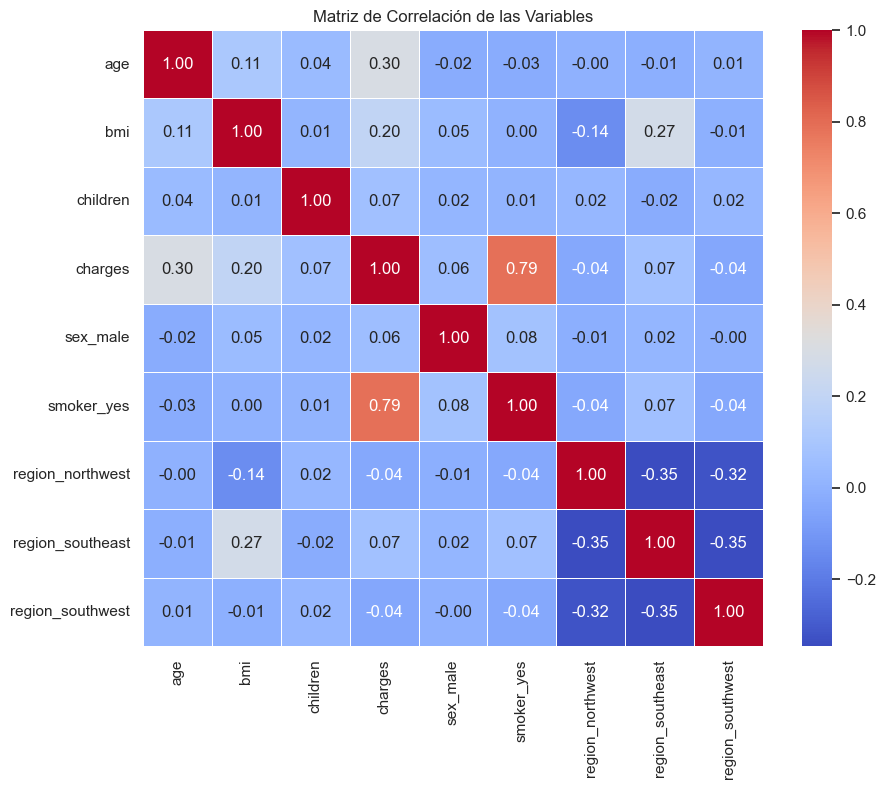

In [6]:
plt.figure(figsize=(10, 8))
# Calculamos la correlación
correlacion = df.corr()
# Dibujamos un mapa de calor (heatmap)
sns.heatmap(correlacion, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Matriz de Correlación de las Variables')
plt.show()

/var/folders/32/g0bfmbps4cl09wf0qn0lsf240000gn/T/ipykernel_10233/790347924.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(ax=axes[0], x='smoker_yes', y='charges', data=df, palette='Set2')


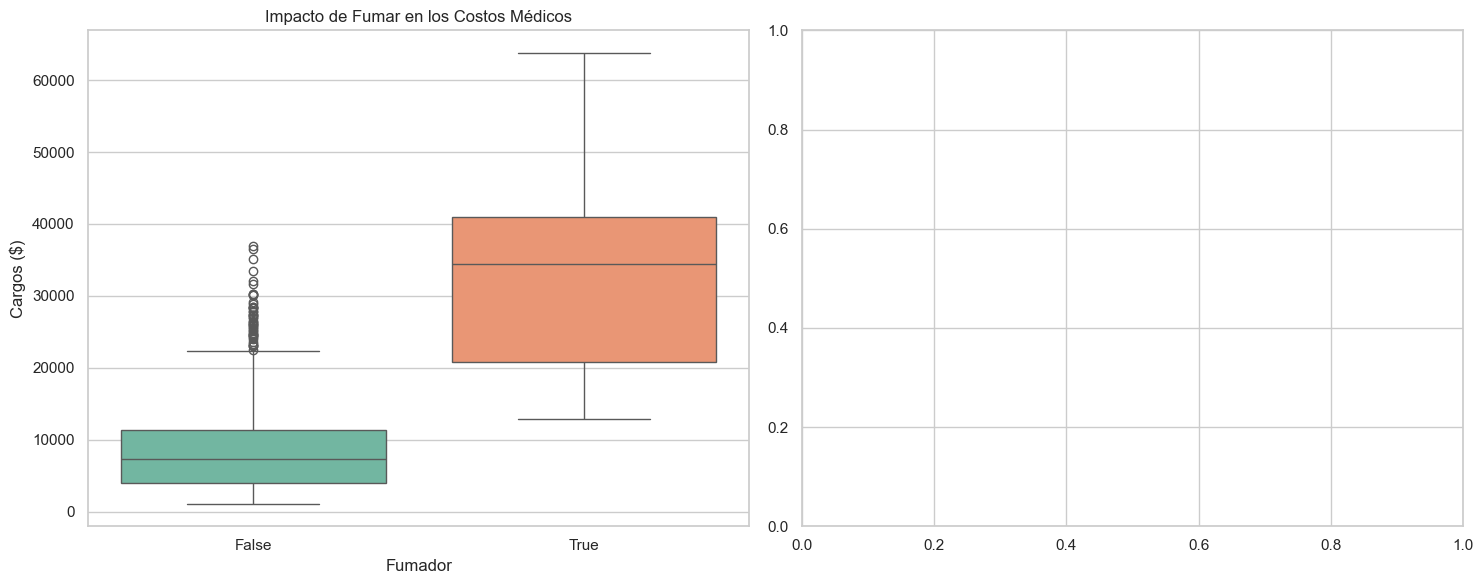

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Boxplot: Fumador vs Cargos
sns.boxplot(ax=axes[0], x='smoker_yes', y='charges', data=df, palette='Set2')
axes[0].set_title('Impacto de Fumar en los Costos Médicos')
axes[0].set_xlabel('Fumador')
axes[0].set_ylabel('Cargos ($)')



plt.tight_layout()
plt.show()

# Neuronal Network

In [8]:
# Separamos 80% para entrenar y 20% para el resto
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.2, random_state=42)

# Ese 20% lo dividimos en dos: 10% para Validar y 10% para el Test final
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)


In [9]:


#Estandarizamos los datos porque las redes neuronales funcionan mejor con datos centrados y escalados
#Si no lo hacemos, algunas características podrían dominar a otras debido a sus diferentes escalas, lo que podría dificultar el aprendizaje del modelo.
scaler = StandardScaler()

# Ajustamos el scaler solo con los datos de entrenamiento para evitar "fugas de información" 
X_train = scaler.fit_transform(X_train)

# Luego transformamos los datos de validación y test usando el mismo scaler para mantener la consistencia
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)



# La red neuronal no entiende tablas de Excel o listas normales, solo entiende "Tensores".
# Convertimos los números a Floats (decimales) para que el motor de PyTorch pueda hacer cálculos rápidos.
X_train = torch.FloatTensor(X_train)
y_train = torch.FloatTensor(y_train)
X_val = torch.FloatTensor(X_val)
y_val = torch.FloatTensor(y_val)

X_test, y_test = torch.FloatTensor(X_test), torch.FloatTensor(y_test)

# Base Model

In [24]:

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error

# 1. Entrenamos el modelo tradicional (Regresión Lineal)
# Usamos los datos antes de ser Tensores (X_train, y_train en formato numpy)
modelo_base = LinearRegression()
modelo_base.fit(X_train.numpy(), y_train.numpy())

# 2. Hacemos predicciones sobre el set de Test
predicciones_base = modelo_base.predict(X_test.numpy())

# 3. Calculamos métricas para tener una referencia
rmse_base = np.sqrt(mean_squared_error(y_test.numpy(), predicciones_base))
mae_base = mean_absolute_error(y_test.numpy(), predicciones_base)

print("--- RESULTADOS DEL MODELO BASE (REGRESIÓN LINEAL) ---")
print(f"Error RMSE (Base): ${rmse_base:.2f}")
print(f"Error MAE (Base): ${mae_base:.2f}")
print("-" * 50)

--- RESULTADOS DEL MODELO BASE (REGRESIÓN LINEAL) ---
Error RMSE (Base): $6012.14
Error MAE (Base): $4320.94
--------------------------------------------------


In [25]:
import optuna

def objective(trial):
    # 1. Sugerimos hiperparámetros (el "robot" elige valores para probar)
    lr = trial.suggest_float("lr", 1e-4, 1e-2, log=True)
    n1 = trial.suggest_int("n1", 32, 256)
    n2 = trial.suggest_int("n2", 16, 128)
    
    # 2. Re-definimos el modelo con esos valores
    class RedOptimizada(nn.Module):
        def __init__(self):
            super().__init__()
            self.capas = nn.Sequential(
                nn.Linear(X_train.shape[1], n1),
                nn.ReLU(),
                nn.Linear(n1, n2),
                nn.ReLU(),
                nn.Linear(n2, 1)
            )
        def forward(self, x): return self.capas(x)

    model_opt = RedOptimizada()
    optimizer_opt = torch.optim.Adam(model_opt.parameters(), lr=lr)
    criterion_opt = nn.MSELoss()

    # 3. Entrenamiento rápido (solo 200 épocas para ir rápido)
    for epoch in range(200):
        model_opt.train()
        optimizer_opt.zero_grad()
        loss = criterion_opt(model_opt(X_train), y_train)
        loss.backward()
        optimizer_opt.step()
    
    # 4. Evaluamos con el set de VALIDACIÓN
    model_opt.eval()
    with torch.no_grad():
        v_loss = criterion_opt(model_opt(X_val), y_val)
    
    return np.sqrt(v_loss.item()) # Optuna intentará minimizar este número

# Lanzamos el estudio (hará 20 intentos automáticos)
study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=20)

print("\n--- ¡BÚSQUEDA FINALIZADA! ---")
print(f"Mejor RMSE encontrado: ${study.best_value:.2f}")
print(f"Mejores parámetros: {study.best_params}")

/Users/anne/Desktop/DeepLearningRepo/deepLearning/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[I 2026-03-24 15:34:17,782] A new study created in memory with name: no-name-92d4b20e-43ef-4a12-a163-11327fcab945
[I 2026-03-24 15:34:19,552] Trial 0 finished with value: 6315.236495967511 and parameters: {'lr': 0.003691640966223231, 'n1': 173, 'n2': 121}. Best is trial 0 with value: 6315.236495967511.
[I 2026-03-24 15:34:20,419] Trial 1 finished with value: 17229.40463277823 and parameters: {'lr': 0.00039932056100643385, 'n1': 73, 'n2': 59}. Best is trial 0 with value: 6315.236495967511.
[I 2026-03-24 15:34:21,392] Trial 2 finished with value: 16668.349888336277 and parameters: {'lr': 0.0014294318371598153, 'n1': 203, 'n2': 24}. Best is trial 0 with value: 6315.236495967511.
[I 2026-03-24 15:34:22,48


--- ¡BÚSQUEDA FINALIZADA! ---
Mejor RMSE encontrado: $5263.59
Mejores parámetros: {'lr': 0.009064524262272155, 'n1': 159, 'n2': 81}


In [26]:
# Definimos la estructura usando los mejores parámetros de Optuna
class RedSeguros(nn.Module):
    def __init__(self, input_dim, n1, n2): # Añadimos n1 y n2 como variables
        super(RedSeguros, self).__init__()
        self.capa1 = nn.Linear(input_dim, n1) 
        self.capa2 = nn.Linear(n1, n2)
        self.salida = nn.Linear(n2, 1)
        self.relu = nn.ReLU()
        
        init.kaiming_normal_(self.capa1.weight)
        init.kaiming_normal_(self.capa2.weight)
        init.kaiming_normal_(self.salida.weight)

    def forward(self, x):
        x = self.relu(self.capa1(x))
        x = self.relu(self.capa2(x))
        return self.salida(x)

# Extraemos los mejores parámetros del estudio de Optuna
params = study.best_params

# Creamos el modelo final con esos parámetros exactos
modelo = RedSeguros(X_train.shape[1], params['n1'], params['n2'])

# Usamos el Learning Rate que encontró Optuna
optimizer = torch.optim.Adam(modelo.parameters(), lr=params['lr'])

In [ ]:
#necesitamos ahora ver cuanto se equivoca la red y como mejorarlo

# La función de pérdida (loss function) mide cuánto se equivoca el modelo. 
# Para problemas de regresión como este, es común usar el MSE que penaliza más los errores grandes.
criterion = nn.MSELoss()

# El optimizer va a ser  el algoritmo que ajusta los pesos de la red para minimizar la pérdida.
optimizer = torch.optim.Adam(modelo.parameters(), lr=params['lr'])   ## Usamos Adam porque es más rápido que el Gradient Descent normal y se adapta solo.

In [ ]:

# 1. Parámetros de control
epochs = 1000              # Número de veces que la red revisará todo el dataset
historial_train = []      # Para guardar el error de entrenamiento
historial_val = []        # Para guardar el error de validación (¡Muy importante!)

print("--- Iniciando el entrenamiento ---")

for epoch in range(epochs):
    # --- FASE DE ENTRENAMIENTO ---
    modelo.train()            
    optimizer.zero_grad()      # Limpiamos los errores anteriores
    
    #La red intenta adivinar los precios
    predicciones = modelo(X_train)
    
    # Calculamos cuánto se ha equivocado
    loss = criterion(predicciones, y_train)
    
    # La red va hacia atras para ver qué falló 
    loss.backward()
    
    # El optimizador ajusta los pesos para mejorar la próxima vez 
    optimizer.step()
    

    # --- FASE DE VALIDACIÓN ---
    # Queremos ver cómo le va con datos que no está memorizando
    modelo.eval()             
    with torch.no_grad():     
        pred_val = modelo(X_val)
        val_loss = criterion(pred_val, y_val)
    
    # Guardamos los errores para ver la evolución
    historial_train.append(loss.item())
    historial_val.append(val_loss.item())
    
    # Imprimimos el progreso cada 50 épocas
    if (epoch + 1) % 50 == 0:
        print(f'Época [{epoch+1}/{epochs}] -> Error Train: {loss.item():.4f} | Error Val: {val_loss.item():.4f}')

print("--- ¡Entrenamiento finalizado! ---")

--- Iniciando el entrenamiento ---
Época [50/1000] -> Error Train: 321278720.0000 | Error Val: 296275616.0000
Época [100/1000] -> Error Train: 317884864.0000 | Error Val: 292970592.0000
Época [150/1000] -> Error Train: 310142432.0000 | Error Val: 285420096.0000
Época [200/1000] -> Error Train: 295878624.0000 | Error Val: 271515264.0000
Época [250/1000] -> Error Train: 273557920.0000 | Error Val: 249813088.0000
Época [300/1000] -> Error Train: 243011840.0000 | Error Val: 220331424.0000
Época [350/1000] -> Error Train: 206081600.0000 | Error Val: 185201808.0000
Época [400/1000] -> Error Train: 166717552.0000 | Error Val: 148589776.0000
Época [450/1000] -> Error Train: 130081352.0000 | Error Val: 115742656.0000
Época [500/1000] -> Error Train: 100635424.0000 | Error Val: 90676632.0000
Época [550/1000] -> Error Train: 79968520.0000 | Error Val: 74025248.0000
Época [600/1000] -> Error Train: 66564448.0000 | Error Val: 63465012.0000
Época [650/1000] -> Error Train: 57791984.0000 | Error Val:

In [31]:

# Pasamos el modelo a modo evaluación 
modelo.eval()

# Desactivamos el cálculo de gradientes para ir más rápido y ahorrar memoria
with torch.no_grad():
    # La red hace el examen final con los datos de Test
    predicciones_finales = modelo(X_test)
    
    # Calculamos el error final (MSE)
    error_final_mse = criterion(predicciones_finales, y_test)

# Convertimos el error en DÓLARES que es lo que entendemos nosotros
# Como usamos MSE, hacemos la raíz cuadrada para tener el RMSE
error_en_dolares = torch.sqrt(error_final_mse).item()

print(f"--- RESULTADO DEL EXAMEN FINAL ---")
print(modelo)

--- RESULTADO DEL EXAMEN FINAL ---
RedSeguros(
  (capa1): Linear(in_features=8, out_features=159, bias=True)
  (capa2): Linear(in_features=159, out_features=81, bias=True)
  (salida): Linear(in_features=81, out_features=1, bias=True)
  (relu): ReLU()
)


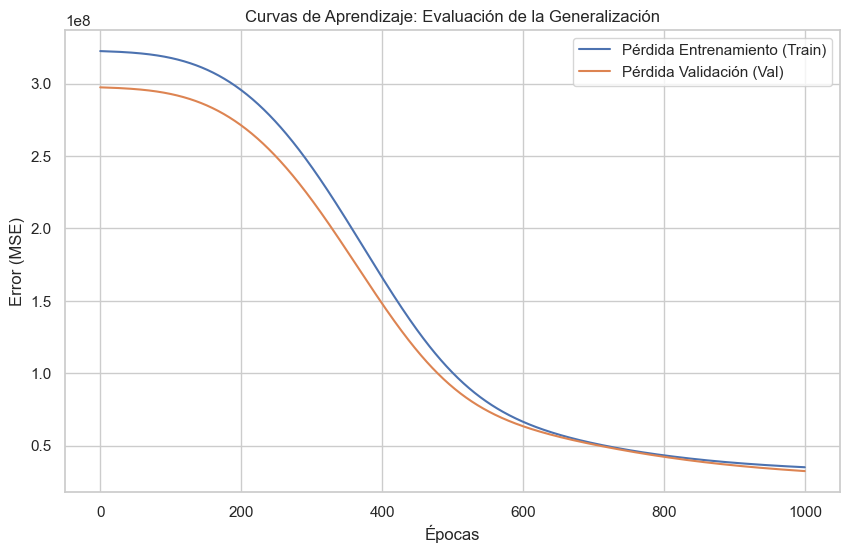

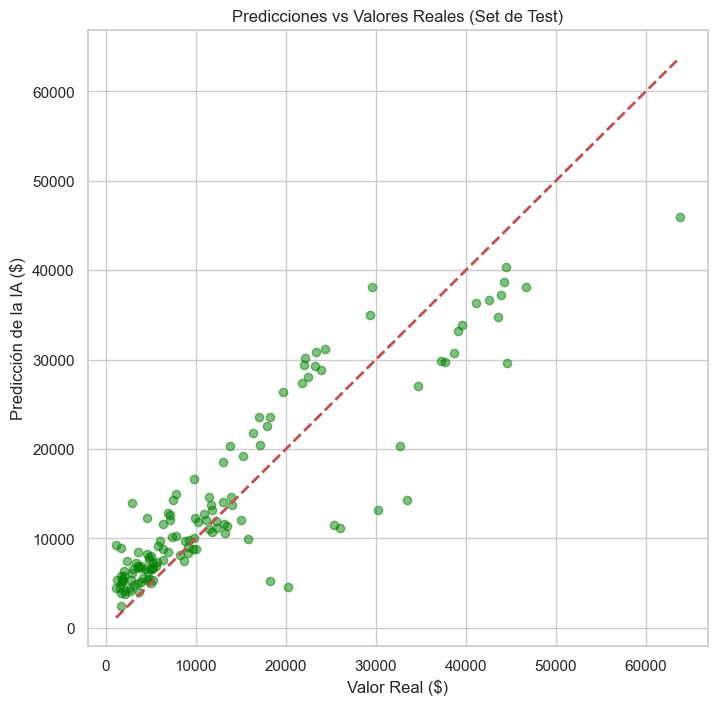

In [32]:


# GRÁFICA DE PÉRDIDA (Comprobación de Overfitting)
# Aquí usamos historial_train e historial_val que llenaste en el bucle
plt.figure(figsize=(10, 6))
plt.plot(historial_train, label='Pérdida Entrenamiento (Train)')
plt.plot(historial_val, label='Pérdida Validación (Val)')
plt.title('Curvas de Aprendizaje: Evaluación de la Generalización')
plt.xlabel('Épocas')
plt.ylabel('Error (MSE)')
plt.legend()
plt.show()

# 2. GRÁFICA DE PREDICCIÓN VS REALIDAD
# Vamos a ver visualmente cuánto se alejan los puntos de la realidad
plt.figure(figsize=(8, 8))
plt.scatter(y_test, predicciones_finales, alpha=0.5, color='green')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.title('Predicciones vs Valores Reales (Set de Test)')
plt.xlabel('Valor Real ($)')
plt.ylabel('Predicción de la IA ($)')
plt.show()